In [1]:
# Local run (no Google Drive mount needed)
import os
print("Running locally. CWD:", os.getcwd())


Running locally. CWD: C:\Users\KONAFA\Desktop\Deep-L


In [35]:
imgSize = (224, 224)
batchSize = 16

In [3]:
# Point this to the folder that contains the 4 dataset subfolders
# This machine (edit if you move the project):
#   ...\Deep-L\deep_project\brainTumorDataPublic_1-766
#   ...\Deep-L\deep_project\brainTumorDataPublic_767-1532
#   ...\Deep-L\deep_project\brainTumorDataPublic_1533-2298
#   ...\Deep-L\deep_project\brainTumorDataPublic_2299-3064
base_path = r"C:\Users\KONAFA\Desktop\Deep-L\deep_project"

# Output folder where we will write real images (PNG) in class subfolders
converted_root = r"C:\Users\KONAFA\Desktop\Deep-L\brainTumor_images_png"

In [4]:
import os

files = os.listdir(base_path)

print("number of files :", len(files))
print(files[:10])

number of files : 4
['brainTumorDataPublic_1-766', 'brainTumorDataPublic_1533-2298', 'brainTumorDataPublic_2299-3064', 'brainTumorDataPublic_767-1532']


In [5]:
photo_path = os.path.join(base_path, 'brainTumorDataPublic_1-766')

In [6]:
files = os.listdir(photo_path)

print("number of files  :", len(files))
print(files[:10])

number of files  : 766
['1.mat', '10.mat', '100.mat', '101.mat', '102.mat', '103.mat', '104.mat', '105.mat', '106.mat', '107.mat']


In [7]:
import os
import csv
import numpy as np
import cv2

# These .mat files can be MATLAB v7.3 (HDF5) or older. We'll support both.
import h5py
import scipy.io

label_map = {
    1: "Meningioma",
    2: "Glioma",
    3: "Pituitary",
}

# Only convert the 4 dataset folders you listed
mat_folders = [
    os.path.join(base_path, "brainTumorDataPublic_1-766"),
    os.path.join(base_path, "brainTumorDataPublic_767-1532"),
    os.path.join(base_path, "brainTumorDataPublic_1533-2298"),
    os.path.join(base_path, "brainTumorDataPublic_2299-3064"),
]


def _as_uint8_grayscale(img: np.ndarray) -> np.ndarray:
    img = np.asarray(img)
    if img.ndim != 2:
        img = np.squeeze(img)
    if img.ndim != 2:
        raise ValueError(f"Expected 2D image after squeeze; got shape {img.shape}")

    img = img.astype(np.float32)
    mn = float(np.min(img))
    mx = float(np.max(img))
    if mx <= mn:
        return np.zeros(img.shape, dtype=np.uint8)

    img = (img - mn) / (mx - mn)
    img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    return img


def _read_cjdata_mat(file_path: str):
    """Return (image_2d, label_int) from a cjdata .mat file."""
    # Try HDF5 (MATLAB v7.3)
    try:
        with h5py.File(file_path, "r") as f:
            if "cjdata" in f:
                g = f["cjdata"]
                img = g["image"][()]
                label = g["label"][()]
                if isinstance(label, np.ndarray) and label.size == 1:
                    label = int(label.item())
                else:
                    label = int(np.array(label).reshape(-1)[0])
                return img, label
    except OSError:
        pass

    # Fallback to classic MAT
    mat = scipy.io.loadmat(file_path)
    if "cjdata" not in mat:
        raise KeyError("cjdata not found")

    cj = mat["cjdata"]
    # cj is typically a 1x1 structured array
    img = cj[0, 0]["image"]
    label = int(cj[0, 0]["label"].item())
    return img, label


def convert_mat_folders_to_png(mat_folders, converted_root: str) -> str:
    os.makedirs(converted_root, exist_ok=True)

    csv_path = os.path.join(converted_root, "index.csv")
    write_header = not os.path.exists(csv_path)

    with open(csv_path, "a", newline="", encoding="utf-8") as fcsv:
        w = csv.writer(fcsv)
        if write_header:
            w.writerow(["png_path", "class_name", "class_id", "mat_path"])

        converted = 0
        skipped = 0

        for folder in mat_folders:
            if not os.path.isdir(folder):
                print("Missing folder:", folder)
                continue

            folder_tag = os.path.basename(folder)
            for name in os.listdir(folder):
                if not name.lower().endswith(".mat"):
                    continue

                mat_path = os.path.join(folder, name)
                stem = os.path.splitext(name)[0]

                try:
                    img, label = _read_cjdata_mat(mat_path)
                    class_name = label_map.get(int(label))
                    if class_name is None:
                        raise ValueError(f"Unknown label {label}")

                    out_dir = os.path.join(converted_root, class_name)
                    os.makedirs(out_dir, exist_ok=True)

                    # Prefix with source folder to avoid collisions like 1.mat in each folder
                    out_name = f"{folder_tag}_{stem}.png"
                    out_path = os.path.join(out_dir, out_name)

                    if os.path.exists(out_path):
                        skipped += 1
                        continue

                    img_u8 = _as_uint8_grayscale(img)
                    ok = cv2.imwrite(out_path, img_u8)
                    if not ok:
                        raise IOError("cv2.imwrite failed")

                    w.writerow([out_path, class_name, int(label) - 1, mat_path])
                    converted += 1

                except Exception as e:
                    print(f"Error converting {mat_path}: {e}")

    print("Conversion done.")
    print("Converted new PNGs:", converted)
    print("Skipped existing PNGs:", skipped)
    print("PNG dataset folder:", converted_root)
    return converted_root


# 1) Convert .mat -> .png (safe to re-run; it skips already-converted files)
convert_mat_folders_to_png(mat_folders, converted_root)


# 2) Load PNGs back into arrays for the rest of the notebook
class_to_id = {"Meningioma": 0, "Glioma": 1, "Pituitary": 2}

images = []
labels = []

for class_name, class_id in class_to_id.items():
    class_dir = os.path.join(converted_root, class_name)
    if not os.path.isdir(class_dir):
        continue

    for fn in os.listdir(class_dir):
        if not fn.lower().endswith(".png"):
            continue
        p = os.path.join(class_dir, fn)
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        images.append(img)
        labels.append(class_id)

print("Total images:", len(images))
print("Total labels:", len(labels))

Conversion done.
Converted new PNGs: 3064
Skipped existing PNGs: 0
PNG dataset folder: C:\Users\KONAFA\Desktop\Deep-L\brainTumor_images_png
Total images: 3064
Total labels: 3064


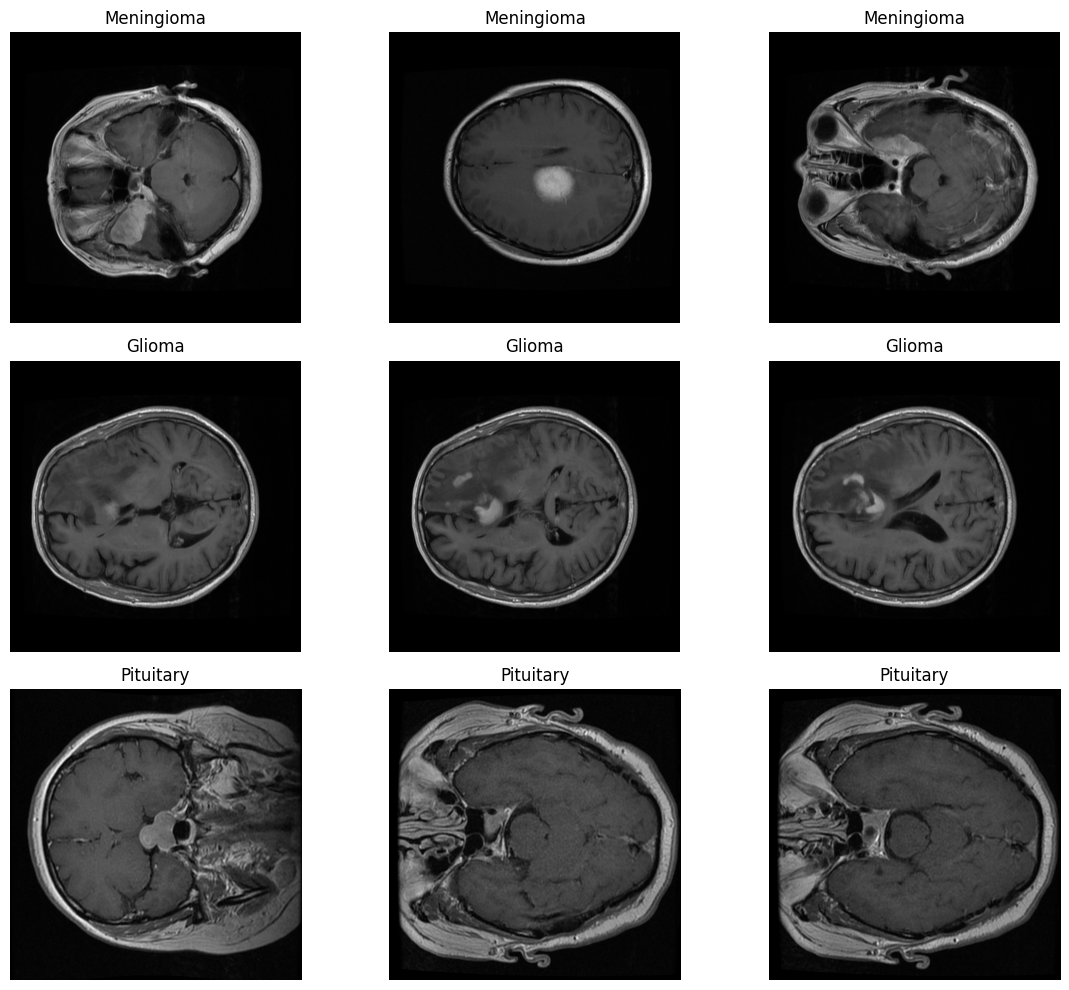

In [8]:
import matplotlib.pyplot as plt
import numpy as np

label_map = {
    0: "Meningioma",
    1: "Glioma",
    2: "Pituitary",
}

unique_labels = np.unique(labels)

fig, axes = plt.subplots(len(unique_labels), 3, figsize=(12, 10))

# لو كلاس واحد بس
if len(unique_labels) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, label_val in enumerate(unique_labels):

    count = 0
    idx_list = []

    for j, val in enumerate(labels):
        if val == label_val:
            idx_list.append(j)
            count += 1
        if count == 3:
            break

    for k in range(min(3, len(idx_list))):
        idx = idx_list[k]

        axes[i, k].imshow(images[idx], cmap='gray')
        axes[i, k].set_title(label_map[int(label_val)])
        axes[i, k].axis('off')

plt.tight_layout()
plt.show()

In [9]:
import cv2
import numpy as np

def preprocess_data(images, labels, img_size=(224,224)):

    processed_images = []

    for img in images:

        # Resize
        img = cv2.resize(img, img_size)

        img = img.astype('float32')

        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)

        # Convert grayscale → RGB
        img = np.stack((img,)*3, axis=-1)

        img = np.clip(img, 0, 1)

        processed_images.append(img)

    images = np.array(processed_images)
    labels = np.array(labels)

    return images, labels

In [10]:
images, labels = preprocess_data(images, labels)
# labels are already 0-indexed because we loaded them from class folders

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    fill_mode='nearest'
)

In [12]:
from sklearn.model_selection import train_test_split

# تقسيم الداتا
X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.2,      # 20% Validation
    random_state=42,
    stratify=labels          # يحافظ على توزيع الكلاسات
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

Train shape: (2451, 224, 224, 3)
Validation shape: (613, 224, 224, 3)
y_train shape: (2451,)
y_val shape: (613,)


In [37]:
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=batchSize
)

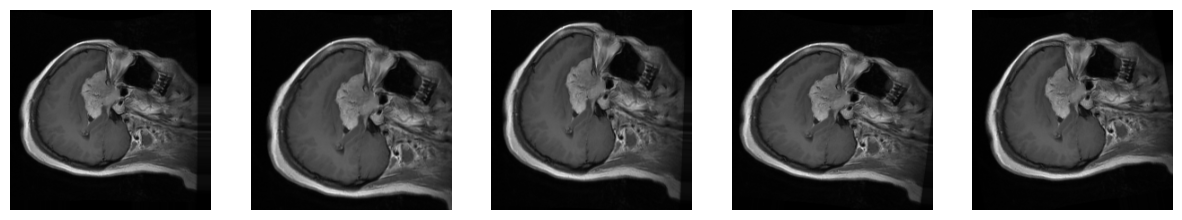

In [14]:
import matplotlib.pyplot as plt

sample_img = X_train[0].reshape((1,) + X_train[0].shape)

augmented_images = train_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 5, figsize=(15,5))

for i in range(5):
    batch = next(augmented_images)
    axes[i].imshow(batch[0])
    axes[i].axis('off')

plt.show()

In [15]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import (
    ResNet50,
    EfficientNetB0,
    DenseNet121,
    MobileNetV2,
    InceptionV3
)

from sklearn.metrics import classification_report, confusion_matrix

In [16]:
def build_model(base_model, input_shape=(224,224,3), num_classes=3):

    for layer in base_model.layers[:-50]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [36]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    mode='max',
    verbose=2
)

In [18]:
def evaluate_model(model, X_val, y_val, model_name):

    loss, accuracy = model.evaluate(X_val, y_val)

    print(f"\n{model_name} Accuracy: {accuracy*100:.2f}%")

    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)

    print("\nClassification Report:\n")
    print(classification_report(y_val, y_pred_classes))

    cm = confusion_matrix(y_val, y_pred_classes)

    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.colorbar()
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [19]:
# 1) ResNet50

resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_model = build_model(resnet_base)

history_resnet = resnet_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[early_stop, reduce_lr]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 87s 1us/step
Epoch 1/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.6532 - loss: 0.7681 - val_accuracy: 0.4666 - val_loss: 0.9644 - learning_rate: 1.0000e-04
Epoch 2/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.7099 - loss: 0.6486 - val_accuracy: 0.4307 - val_loss: 1.1408 - learning_rate: 1.0000e-04
Epoch 3/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.7474 - loss: 0.5610 - val_accuracy: 0.8140 - val_loss: 0.4366 - learning_rate: 1.0000e-04
Epoch 4/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.7646 - loss: 0.5237 - val_accuracy: 0.7569 - val_loss: 0.5037 - learning_rate: 1.0000e-04
Epoch 5/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.7793 - loss: 0.5231 - val_accuracy: 0.6933 - val_loss: 1.5092 - learning_rate: 1.0000e-04
Epoch 6/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7754 - loss: 0.5095
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
77/77 ━

20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8711 - loss: 0.2750

ResNet50 Accuracy: 87.11%
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.73      0.74       142
           1       0.89      0.86      0.88       285
           2       0.93      0.99      0.96       186

    accuracy                           0.87       613
   macro avg       0.86      0.86      0.86       613
weighted avg       0.87      0.87      0.87       613



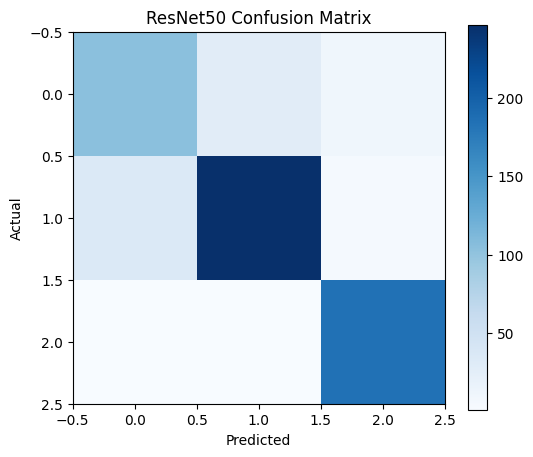

In [20]:
evaluate_model(resnet_model, X_val, y_val, "ResNet50")

In [21]:
# 2) EfficientNetB0

efficientnet_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

efficientnet_model = build_model(efficientnet_base)

history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[early_stop, reduce_lr]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step
Epoch 1/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.4308 - loss: 1.0959 - val_accuracy: 0.4649 - val_loss: 1.0723 - learning_rate: 1.0000e-04
Epoch 2/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 76s 987ms/step - accuracy: 0.4361 - loss: 1.0794 - val_accuracy: 0.4649 - val_loss: 1.0594 - learning_rate: 1.0000e-04
Epoch 3/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.4625 - loss: 1.0662
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
77/77 ━━━━━━━━━━━━━━━━━━━━ 76s 990ms/step - accuracy: 0.4451 - loss: 1.0687 - val_accuracy: 0.4649 - val_loss: 1.0673 - learning_rate: 1.0000e-04
Epoch 4/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 76s 988ms/step - accuracy: 0.4512 - loss: 1.0658 - val_accuracy: 0.4649 - val_loss: 1.0675 - learning_rate: 2.0000e-05
Epoch 5/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 76s 986ms/step - accuracy: 0.4586 - loss: 1.0588 - val_accuracy: 0.4649 - val_loss: 1.0608 - learning_rate: 2.0000e-05
Epoch 6/2

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 548ms/step - accuracy: 0.4649 - loss: 1.0723

EfficientNetB0 Accuracy: 46.49%
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 642ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       142
           1       0.46      1.00      0.63       285
           2       0.00      0.00      0.00       186

    accuracy                           0.46       613
   macro avg       0.15      0.33      0.21       613
weighted avg       0.22      0.46      0.30       613



C:\Users\KONAFA\Desktop\Deep-L\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KONAFA\Desktop\Deep-L\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KONAFA\Desktop\Deep-L\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

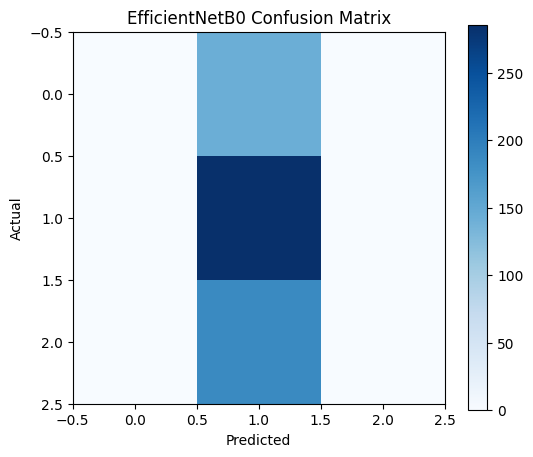

In [22]:
evaluate_model(efficientnet_model, X_val, y_val, "EfficientNetB0")

In [38]:
# 3) DenseNet121

densenet_base = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

densenet_model = build_model(densenet_base)

history_densenet = densenet_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.6569 - loss: 0.7907 - val_accuracy: 0.8499 - val_loss: 0.4104 - learning_rate: 1.0000e-04
Epoch 2/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 153s 993ms/step - accuracy: 0.8033 - loss: 0.4758 - val_accuracy: 0.8744 - val_loss: 0.3048 - learning_rate: 1.0000e-04
Epoch 3/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8572 - loss: 0.3504 - val_accuracy: 0.9070 - val_loss: 0.2388 - learning_rate: 1.0000e-04
Epoch 4/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 153s 990ms/step - accuracy: 0.8768 - loss: 0.3094 - val_accuracy: 0.9184 - val_loss: 0.2119 - learning_rate: 1.0000e-04
Epoch 5/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 148s 958ms/step - accuracy: 0.9074 - loss: 0.2524 - val_accuracy: 0.9282 - val_loss: 0.2193 - learning_rate: 1.0000e-04
Epoch 6/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 144s 934ms/step - accuracy: 0.9135 - loss: 0.2321 - val_accuracy: 0.9233 - val_loss: 0.1785 - learning_rate: 1.0000e-04
Epoch 7/200
154/154 ━━━━━━━━━━━━━━━━━━━━

20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9657 - loss: 0.1073

DenseNet121 Accuracy: 96.57%
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       142
           1       0.98      0.96      0.97       285
           2       0.96      1.00      0.98       186

    accuracy                           0.97       613
   macro avg       0.96      0.96      0.96       613
weighted avg       0.97      0.97      0.97       613



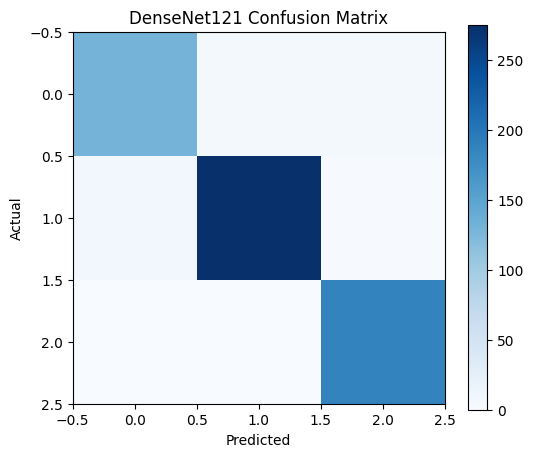

In [39]:
evaluate_model(densenet_model, X_val, y_val, "DenseNet121")

In [25]:
# 4) MobileNetV2

mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_model = build_model(mobilenet_base)

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[early_stop, reduce_lr]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step
Epoch 1/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 72s 842ms/step - accuracy: 0.7976 - loss: 0.4952 - val_accuracy: 0.6069 - val_loss: 1.0149 - learning_rate: 1.0000e-04
Epoch 2/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 63s 818ms/step - accuracy: 0.9045 - loss: 0.2603 - val_accuracy: 0.5498 - val_loss: 1.8642 - learning_rate: 1.0000e-04
Epoch 3/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.9242 - loss: 0.1947
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
77/77 ━━━━━━━━━━━━━━━━━━━━ 63s 823ms/step - accuracy: 0.9217 - loss: 0.2006 - val_accuracy: 0.6705 - val_loss: 1.0978 - learning_rate: 1.0000e-04
Epoch 4/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 63s 821ms/step - accuracy: 0.9453 - loss: 0.1419 - val_accuracy: 0.7096 - val_loss: 0.8928 - learning_rate: 2.0000e-05
Epoch 5/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 63s 818ms/step - accuracy: 0.9584 - loss: 0.1242 - val_accuracy: 0.7455 - val_loss: 0.7640 - learning_rate: 2.0000e-05
Epoch 6/2

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 416ms/step - accuracy: 0.6069 - loss: 1.0149

MobileNetV2 Accuracy: 60.69%
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 467ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.10      0.18       142
           1       0.54      1.00      0.71       285
           2       0.99      0.39      0.56       186

    accuracy                           0.61       613
   macro avg       0.80      0.50      0.48       613
weighted avg       0.76      0.61      0.54       613



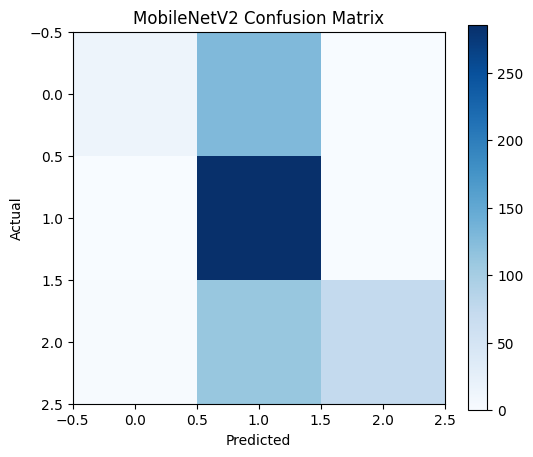

In [26]:
evaluate_model(mobilenet_model, X_val, y_val, "MobileNetV2")

In [27]:
# 5) InceptionV3

inception_base = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

inception_model = build_model(inception_base)

history_inception = inception_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[early_stop, reduce_lr]
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 82s 1us/step
Epoch 1/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.7630 - loss: 0.5621 - val_accuracy: 0.7961 - val_loss: 0.4448 - learning_rate: 1.0000e-04
Epoch 2/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8841 - loss: 0.2969 - val_accuracy: 0.8760 - val_loss: 0.2947 - learning_rate: 1.0000e-04
Epoch 3/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.9146 - loss: 0.2313
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9147 - loss: 0.2240 - val_accuracy: 0.8662 - val_loss: 0.2973 - learning_rate: 1.0000e-04
Epoch 4/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9290 - loss: 0.1843 - val_accuracy: 0.9119 - val_loss: 0.2212 - learning_rate: 2.0000e-05
Epoch 5/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9335 - loss: 0.1806 - val_accuracy: 0.9217 - val_loss: 0.2076 - learning_rate: 2.0000e-05
Epoch 6/200
77/77 ━━━

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 696ms/step - accuracy: 0.7961 - loss: 0.4448

InceptionV3 Accuracy: 79.61%
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 794ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.58      0.62       142
           1       0.77      0.93      0.84       285
           2       0.97      0.75      0.84       186

    accuracy                           0.80       613
   macro avg       0.80      0.76      0.77       613
weighted avg       0.81      0.80      0.79       613



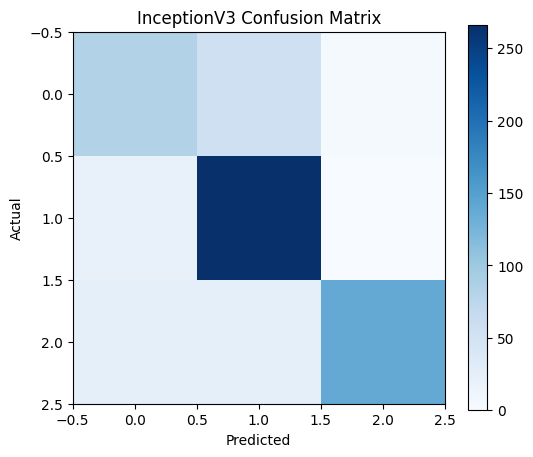

In [28]:
evaluate_model(inception_model, X_val, y_val, "InceptionV3")

In [ ]:
# Evaluate All Models

models = {
    "ResNet50": resnet_model,
    "EfficientNetB0": efficientnet_model,
    "DenseNet121": densenet_model,
    "MobileNetV2": mobilenet_model,
    "InceptionV3": inception_model
}

results = {}

for name, model in models.items():

    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)

    results[name] = accuracy * 100

    print(f"{name}: {accuracy*100:.2f}%")

ResNet50: 87.11%


In [ ]:
# Compare Models

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])

In [ ]:
# Plot Accuracy Comparison

plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.ylabel('Accuracy %')
plt.title('Pretrained CNN Models Comparison')
plt.xticks(rotation=15)

plt.show()